# DFT-D3 in xnn: reproducing examples of the two Grimme papers

[Grimme, Antony, Ehrlich & Krieg, *J. Chem. Phys.* **132**, 154104 (2010)](https://doi.org/10.1063/1.3382344)
introduced DFT-D3: *ab initio* (TD-DFT) reference $C_6$ coefficients for all elements
H–Pu, interpolated in a **fractional coordination number** (eqs 15–16), recursively
derived $C_8$ (eqs 6–9), a zero-damping pair sum (eqs 3–4) and an optional three-body
Axilrod–Teller–Muto term (eqs 11–14). [Grimme, Ehrlich & Goerigk, *J. Comput. Chem.*
**32**, 1456 (2011)](https://doi.org/10.1002/jcc.21759) replaced the zero damping by
the rational Becke–Johnson damping (eqs 5–7), which damps to a finite value at short
range and became the default. This notebook uses xnn's independent implementation
(`xnn.common.models.D3Dispersion`, verified against the reference `simple-dftd3` in
`examples/fidelity_checks/d3_verification.ipynb`) to reproduce, without external
quantum-chemistry data:

1. **table II (2010)**: the free-atom rare-gas $C_6$ and the sp³/sp²/sp carbon $C_6$;
2. **table III (2010)**: rare-gas trimer $C_9$ from the geometric-mean approximation of eq 13;
3. **fig 5 (2010)**: the CN dependence of $C_6^{CC}$, $C_6^{NN}$, $C_6^{OO}$;
4. **fig 1 (2010)**: the dispersion energy of two carbon atoms with the BLYP and TPSS parameters and the size of the $C_8$ term;
5. **fig 1 (2011)**: the argon dimer with zero vs BJ damping (TPSS) against the undamped $-C_6/R^6$;
6. **table VII (2010)**: the three-body share of the graphene bilayer binding;
7. **fig 6 (2010)**: molecular $C_6$ coefficients against DOSD reference data.

Parameters: PBE0-D3(BJ) `s8 = 1.2177, a1 = 0.4145, a2 = 4.8593` (2011 table 2) and
PBE0-D3(0) `sr6 = 1.287, s8 = 0.928` (2010 table IV) are xnn's defaults; the figures
use the BLYP / TPSS sets of the papers where the papers do.


In [1]:
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import Atoms
from ase.build import molecule

torch.set_default_dtype(torch.float64)

import xnn
from xnn.common.data import structure_to_graph
from xnn.common.models import D3Dispersion, DFTD3
from xnn.common.models.d3 import PBE0_D3BJ, PBE0_D3ZERO
from xnn.common.models.dispersion import BOHR, HARTREE

KCAL = HARTREE / 0.0433641153087705      # hartree -> kcal/mol via eV
print("xnn", xnn.__version__, "| PBE0-D3(BJ):", PBE0_D3BJ, "| PBE0-D3(0):", PBE0_D3ZERO)

def run(atoms, model):
    s = {"pos": atoms.positions, "atomic_numbers": atoms.numbers}
    if atoms.pbc.any():
        s["cell"], s["pbc"] = atoms.cell[:], atoms.pbc
    return {k: v.detach() for k, v in model(structure_to_graph(s, model.cutoff)).items()}

core = DFTD3()

def c6_at_cn(Z, cn):
    z = torch.full((len(cn),), Z, dtype=torch.long); cn_t = torch.as_tensor(np.asarray(cn, dtype=float))
    w = core.reference_weights(z, cn_t)
    return core.c6_matrix(z, w, core._species_vectors(z, w)).diagonal().numpy()


xnn 0.2.1 | PBE0-D3(BJ): {'s6': 1.0, 's8': 1.2177, 'a1': 0.4145, 'a2': 4.8593, 's9': 0.0, 'alp': 14.0} | PBE0-D3(0): {'s6': 1.0, 's8': 0.928, 'rs6': 1.287, 'rs8': 1.0, 's9': 0.0, 'alp': 14.0}


## 1. Reference $C_6$ coefficients · table II (2010)

Table II compares the TD-DFT (PBE38/daug-def2-QZVP) $C_6$ of the free rare-gas atoms
with reference values, and gives the carbon $C_6$ in ethane, ethene and ethyne obtained
with the partitioning of eq 10. Both sets are reference systems of the D3 table: the
free atoms are the CN = 0 references, the three carbons are the CN ≈ 4, 3, 2 references.


In [2]:
rows = [("He-He", 2, 0, 1.46, 1.54), ("Ne-Ne", 10, 0, 6.35, 6.14), ("Ar-Ar", 18, 0, 64.4, 64.2), ("Kr-Kr", 36, 0, 130.1, 129.7),
        ("Xe-Xe", 54, 0, 287.5, 288.6), ("Rn-Rn", 86, 0, 420.6, 410.5),
        ("C-C (sp3)", 6, 4, 22.4, 18.1), ("C-C (sp2)", 6, 3, 27.4, 25.7), ("C-C (sp)", 6, 2, 29.7, 29.3)]
print(f"{'pair':10s} {'ref. value':>11s} {'paper TDDFT':>12s} {'xnn D3 table':>13s} {'CN of ref.':>11s}")
for name, Z, ref, exp, paper in rows:
    print(f"{name:10s} {exp:11.2f} {paper:12.2f} {float(core.c6ref[ref, ref, Z, Z]):13.2f} {float(core.refcn[ref, Z]):11.4f}")


pair        ref. value  paper TDDFT  xnn D3 table  CN of ref.
He-He             1.46         1.54          1.56      0.0000
Ne-Ne             6.35         6.14          6.29      0.0000
Ar-Ar            64.40        64.20         64.65      0.0000
Kr-Kr           130.10       129.70        130.40      0.0000
Xe-Xe           287.50       288.60        290.22      0.0000
Rn-Rn           420.60       410.50        412.83      0.0000
C-C (sp3)        22.40        18.10         18.21      3.9844
C-C (sp2)        27.40        25.70         25.78      2.9987
C-C (sp)         29.70        29.30         29.36      1.9985


## 2. Rare-gas trimer $C_9$ · table III (2010), eq 13

The three-body coefficient is approximated by the geometric mean
$C_9^{ABC} \approx \sqrt{C_6^{AB} C_6^{BC} C_6^{CA}}$ (eq 13, "DFT-D3" column of table
III, given as $-C_9$), which the paper compares with the TD-DFT integration (eq 12) and
with experiment. The column follows from the free-atom $C_6$ of the D3 table.


In [3]:
trimers = [("Ne Ne Ne", (10, 10, 10), 15.8, 11.6, 11.9), ("Ne Ar Kr", (10, 18, 36), 219.1, 203.5, 204.8), ("Ar Ar Ar", (18, 18, 18), 519.8, 523.0, 519.0),
           ("Ar Kr Kr", (18, 36, 36), 1047, 1100, 1087), ("Kr Kr Kr", (36, 36, 36), 1489, 1600, 1577), ("Ar Kr Xe", (18, 36, 54), 1554, 1669, 1647),
           ("Kr Xe Xe", (36, 54, 54), 3306, 3716, 3656), ("Xe Xe Xe", (54, 54, 54), 4944, 5694, 5595)]
print(f"{'atoms':10s} {'D3 eq 13 (paper)':>17s} {'xnn eq 13':>10s} {'TDDFT eq 12':>12s} {'expt':>7s}")
for name, (a, b, c), paper, tddft, expt in trimers:
    c9 = float(torch.sqrt(core.c6ref[0, 0, a, b] * core.c6ref[0, 0, b, c] * core.c6ref[0, 0, a, c]))
    print(f"{name:10s} {paper:17.1f} {c9:10.1f} {tddft:12.1f} {expt:7.1f}")


atoms       D3 eq 13 (paper)  xnn eq 13  TDDFT eq 12    expt
Ne Ne Ne                15.8       15.8         11.6    11.9
Ne Ar Kr               219.1      219.1        203.5   204.8
Ar Ar Ar               519.8      519.8        523.0   519.0
Ar Kr Kr              1047.0     1046.5       1100.0  1087.0
Kr Kr Kr              1489.0     1489.1       1600.0  1577.0
Ar Kr Xe              1554.0     1554.4       1669.0  1647.0
Kr Xe Xe              3306.0     3306.2       3716.0  3656.0
Xe Xe Xe              4944.0     4944.2       5694.0  5595.0


## 3. $C_6$ vs coordination number · fig 5 (2010)

The Gaussian interpolation (eq 16, $k_3 = 4$) between the reference systems gives smooth
$C_6(\mathrm{CN})$ curves with plateaus at the integer coordination numbers; the paper
notes the ~25% drop of the carbon $C_6$ between sp² and sp³ and the much larger drop from
the free atom.


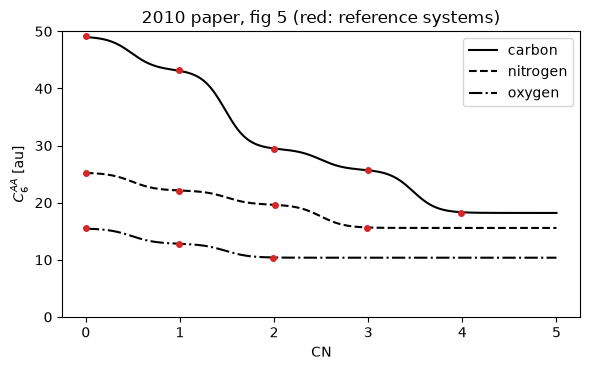

In [4]:
cn = np.linspace(0, 5, 401)
fig, ax = plt.subplots(figsize=(6, 3.8))
for Z, name, ls in [(6, "carbon", "-"), (7, "nitrogen", "--"), (8, "oxygen", "-.")]:
    ax.plot(cn, c6_at_cn(Z, cn), "k", ls=ls, label=name)
    nref = int(core.nref[Z]); ax.plot(core.refcn[:nref, Z].numpy(), [float(core.c6ref[r, r, Z, Z]) for r in range(nref)], "o", ms=4, color="C3")
ax.set_xlabel("CN"); ax.set_ylabel(r"$C_6^{AA}$ [au]"); ax.set_ylim(0, 50); ax.legend(); ax.set_title("2010 paper, fig 5 (red: reference systems)")
plt.tight_layout(); plt.show()


## 4. Dispersion energy of two carbon atoms · fig 1 (2010)

Fig 1 shows the total dispersion energy (and the $C_8$ part alone) of two three-fold
coordinated carbon atoms with the BLYP-D3 ($s_{r,6} = 1.094$, $s_8 = 1.682$) and
TPSS-D3 ($s_{r,6} = 1.166$, $s_8 = 1.105$) zero-damping parameters of table IV. The
minimum sits at the typical van der Waals distance (3.3–3.4 Å) and the $C_8$ term is a
large part of it at short range. Here the two carbons are taken as sp² references (CN = 3)
by evaluating the pair with fixed reference weights, exactly as the figure intends.


BLYP-D3: minimum -0.250 kcal/mol at R(C-C) = 3.33 Å
TPSS-D3: minimum -0.153 kcal/mol at R(C-C) = 3.33 Å


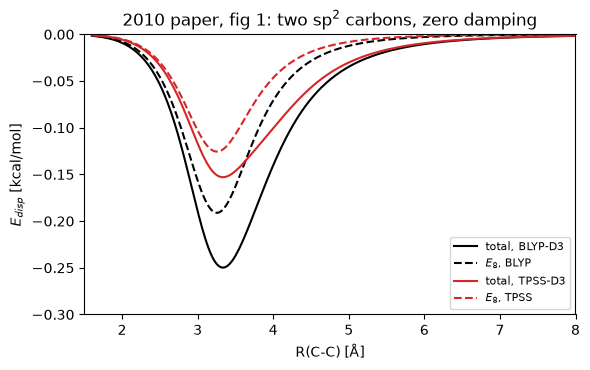

In [5]:
def two_carbon_curve(rs6, s8, s8_only=False):
    # fixed CN = 3 weights -> C6 of the sp2 reference; damped pair energy of eq 3/4 in kcal/mol
    model = DFTD3(damping="zero", rs6=rs6, s8=s8, s6=0.0 if s8_only else 1.0)
    z = torch.tensor([6, 6]); w = model.reference_weights(z, torch.tensor([3.0, 3.0]))
    c6 = float(model.c6_matrix(z, w, model._species_vectors(z, w))[0, 1])
    r = np.linspace(1.6, 8.0, 300) / BOHR
    rr = 3 * float(model.r4r2[6]) ** 2; r0 = float(model.rvdw[6, 6])
    f6 = 1 / (1 + 6 * (rs6 * r0 / r) ** 14); f8 = 1 / (1 + 6 * (r0 / r) ** 16)
    e = -c6 * ((0.0 if s8_only else 1.0) * f6 / r ** 6 + s8 * rr * f8 / r ** 8)
    return r * BOHR, e * KCAL

fig, ax = plt.subplots(figsize=(6, 3.8))
for (rs6, s8, name, color) in [(1.094, 1.682, "BLYP-D3", "k"), (1.166, 1.105, "TPSS-D3", "C3")]:
    R, e = two_carbon_curve(rs6, s8); ax.plot(R, e, color=color, label=f"total, {name}")
    R, e8 = two_carbon_curve(rs6, s8, s8_only=True); ax.plot(R, e8, color=color, ls="--", label=f"$E_8$, {name.split('-')[0]}")
    print(f"{name}: minimum {e.min():.3f} kcal/mol at R(C-C) = {R[e.argmin()]:.2f} Å")
ax.set_xlim(1.5, 8); ax.set_ylim(-0.3, 0.0); ax.set_xlabel("R(C-C) [Å]"); ax.set_ylabel(r"$E_{disp}$ [kcal/mol]"); ax.legend(fontsize=8)
ax.set_title("2010 paper, fig 1: two sp$^2$ carbons, zero damping"); plt.tight_layout(); plt.show()


## 5. Zero vs BJ damping on the argon dimer · fig 1 (2011)

The 2011 paper's fig 1 contrasts the two damping philosophies on Ar₂ with TPSS parameters
(zero: $s_{r,6} = 1.166$, $s_8 = 1.105$; BJ: $a_1 = 0.4535$, $s_8 = 1.9435$,
$a_2 = 4.4752$): zero damping removes the correction below ~3.3 Å and passes through a
minimum of about −0.45 kcal/mol, BJ damping saturates to a finite value (about −0.7
kcal/mol) at $R \to 0$; both follow the undamped $-C_6/R^6$ at long range.


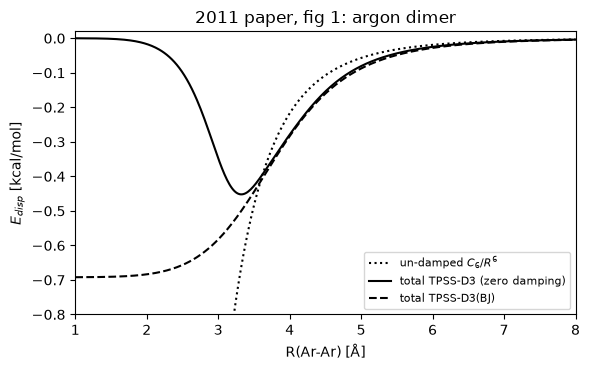

zero damping: minimum -0.452 kcal/mol at 3.32 Å;  BJ damping: E(R -> 1 Å) = -0.692 kcal/mol;  C6(Ar-Ar) = 64.6 au


In [6]:
R = np.linspace(1.0, 8.0, 400)
ar2 = [Atoms("Ar2", positions=[[0, 0, 0], [x, 0, 0]]) for x in R]
zero = D3Dispersion(damping="zero", rs6=1.166, s8=1.105)
bj = D3Dispersion(damping="bj", a1=0.4535, s8=1.9435, a2=4.4752)
e_zero = np.array([float(run(a, zero)["energy"]) for a in ar2]) / HARTREE * KCAL
e_bj = np.array([float(run(a, bj)["energy"]) for a in ar2]) / HARTREE * KCAL
out = run(ar2[-1], bj); c6 = float(out["c6_matrix"][0, 1])
plt.figure(figsize=(6, 3.8))
plt.plot(R, -c6 / (R / BOHR) ** 6 * KCAL, "k:", label=r"un-damped $C_6/R^6$")
plt.plot(R, e_zero, "k-", label="total TPSS-D3 (zero damping)")
plt.plot(R, e_bj, "k--", label="total TPSS-D3(BJ)")
plt.ylim(-0.8, 0.02); plt.xlim(1, 8); plt.xlabel("R(Ar-Ar) [Å]"); plt.ylabel(r"$E_{disp}$ [kcal/mol]"); plt.legend(fontsize=8)
plt.title("2011 paper, fig 1: argon dimer"); plt.tight_layout(); plt.show()
print(f"zero damping: minimum {e_zero.min():.3f} kcal/mol at {R[e_zero.argmin()]:.2f} Å;  BJ damping: E(R -> 1 Å) = {e_bj[0]:.3f} kcal/mol;  C6(Ar-Ar) = {c6:.1f} au")


## 6. Three-body share of the graphene bilayer binding · table VII (2010)

Table VII lists the interlayer dissociation energy of two graphene sheets: including
$E^{(3)}$ lowers the DFT-D3 values by about 5 meV/atom (BLYP: 59 → 54, B97-D: 52 → 46,
revPBE: 55 → 49, PBE: 41 → 35, TPSS: 48 → 43 meV/atom), "about 10%" of the binding. The
dispersion part of that number is reproduced here with a periodic AB-stacked bilayer at
the experimental spacing (3.35 Å): the two-body D3 binding and the (repulsive) three-body
contribution per atom, for the five functionals of the table (zero damping, table IV
parameters).


In [7]:
from ase.lattice.hexagonal import Graphite

def bilayer(sep=3.35, vacuum=25.0):
    g = Graphite("C", latticeconstant={"a": 2.46, "c": 2 * sep})   # AB-stacked, 4 atoms: two layers per cell
    cell = g.cell[:].copy(); cell[2, 2] = 2 * sep + vacuum          # isolate one bilayer
    g.set_cell(cell, scale_atoms=False)
    return g

def sheet(vacuum=25.0):
    g = bilayer(); return g[g.positions[:, 2] < 1.0]                 # one of the two layers

params = {"BLYP": (1.094, 1.682), "B97-D": (0.892, 0.909), "revPBE": (0.923, 1.010), "PBE": (1.217, 0.722), "TPSS": (1.166, 1.105)}
table7 = {"BLYP": (59, 54), "B97-D": (52, 46), "revPBE": (55, 49), "PBE": (41, 35), "TPSS": (48, 43)}
print(f"{'DF':8s} {'E2 disp. binding':>17s} {'E3 (repulsive)':>15s} {'E3 / E2':>8s}   {'paper D3 -> D3+E3 (total, meV/atom)':>36s}")
for df, (rs6, s8) in params.items():
    model = D3Dispersion(damping="zero", rs6=rs6, s8=s8, s9=1.0)
    b, s = run(bilayer(), model), run(sheet(), model)
    e2 = (float(b["energy_2body"]) - 2 * float(s["energy_2body"])) / 4 * 1e3   # meV per atom of the bilayer
    e3 = (float(b["energy_3body"]) - 2 * float(s["energy_3body"])) / 4 * 1e3
    print(f"{df:8s} {e2:17.1f} {e3:15.1f} {e3 / abs(e2) * 100:7.1f}%   {table7[df][0]:>12d} -> {table7[df][1]}")
print("\n(the DFT part of the binding is not included: the columns give the dispersion contributions only)")


DF        E2 disp. binding  E3 (repulsive)  E3 / E2    paper D3 -> D3+E3 (total, meV/atom)
BLYP                 -48.8             3.4     6.9%             59 -> 54


B97-D                -45.9             3.4     7.3%             52 -> 46
revPBE               -46.8             3.4     7.2%             55 -> 49


PBE                  -28.1             3.4    12.0%             41 -> 35
TPSS                 -36.3             3.4     9.3%             48 -> 43

(the DFT part of the binding is not included: the columns give the dispersion contributions only)


## 7. Molecular $C_6$ coefficients vs DOSD · fig 6 (2010)

Fig 6 compares molecular $C_6$ coefficients (sum of all intramolecular pairs, eq 16) with
experimental dipole-oscillator-strength-distribution values for 174 pairs and reports a
mean absolute deviation of 8.4%. The same small-molecule subset as in the D4 example
notebook is used here (reference values transcribed from the literature; **treat them
as approximate orientation**, see the caveat there), evaluated with both D3 and D4.


molecule      DOSD       D3       D4  dev D3 %  dev D4 %
H2            12.1     12.5     12.2      +3.7      +1.2
N2            73.4     88.5     82.4     +20.6     +12.3
O2            62.0     51.3     60.1     -17.3      -3.0
CO            81.4    100.8     96.1     +23.9     +18.1
CO2          158.7    156.4    175.4      -1.4     +10.5
N2O          184.9    161.0    170.8     -12.9      -7.6
NH3           89.1     84.7     84.1      -5.0      -5.6
H2O           45.4     44.5     44.5      -1.9      -2.1
CH4          129.7    127.7    123.8      -1.6      -4.5
C2H2         204.1    206.7    206.1      +1.3      +1.0
C2H4         300.2    294.5    294.2      -1.9      -2.0
C2H6         381.9    364.0    362.1      -4.7      -5.2
C3H8         768.1    721.1    726.7      -6.1      -5.4
C6H6        1723.0   1659.7   1764.8      -3.7      +2.4
HF            19.0     18.9     19.0      -0.5      -0.1
HCl          130.4    126.9    127.1      -2.7      -2.5
Cl2          389.2    361.7    

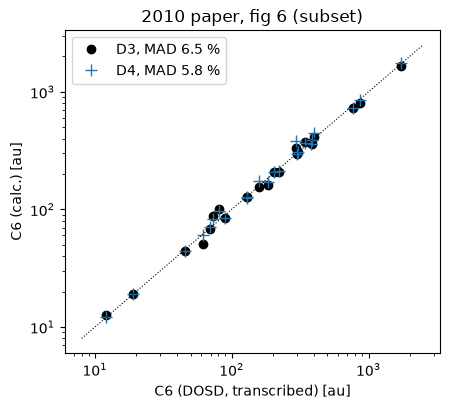

In [8]:
from xnn.common.models import D4Dispersion, c6_matrix
dosd = {"H2": 12.1, "N2": 73.4, "O2": 62.0, "CO": 81.4, "CO2": 158.7, "N2O": 184.9, "NH3": 89.1, "H2O": 45.4, "CH4": 129.7,
        "C2H2": 204.1, "C2H4": 300.2, "C2H6": 381.9, "C3H8": 768.1, "C6H6": 1723.0, "HF": 19.0, "HCl": 130.4, "Cl2": 389.2,
        "SO2": 294.0, "CS2": 871.1, "OCS": 402.2, "NO": 69.8, "CH3OH": 222.0, "SiH4": 343.9, "PH3": 307.5}
d3 = D3Dispersion(); d4 = D4Dispersion()
rows = []
for name, ref in dosd.items():
    a = molecule(name)
    c3 = float(run(a, d3)["c6_matrix"].sum()); c4 = float(c6_matrix(run(a, d4)["dynamic_polarizabilities"]).sum())
    rows.append((name, ref, c3, c4))
dev3 = np.array([(r[2] / r[1] - 1) * 100 for r in rows]); dev4 = np.array([(r[3] / r[1] - 1) * 100 for r in rows])
print(f"{'molecule':9s} {'DOSD':>8s} {'D3':>8s} {'D4':>8s} {'dev D3 %':>9s} {'dev D4 %':>9s}")
for (name, ref, c3, c4), e3, e4 in zip(rows, dev3, dev4):
    print(f"{name:9s} {ref:8.1f} {c3:8.1f} {c4:8.1f} {e3:+9.1f} {e4:+9.1f}")
print(f"\nMAD: D3 {np.abs(dev3).mean():.1f} %  D4 {np.abs(dev4).mean():.1f} %   (2010 paper, 174 DOSD pairs: D3 8.4 %, Becke-Johnson 12.2 %; 2019 D4 paper: D3 4.7 %, D4 3.8 %)")
plt.figure(figsize=(4.6, 4.2))
ref = np.array([r[1] for r in rows])
plt.loglog(ref, [r[2] for r in rows], "ko", label=f"D3, MAD {np.abs(dev3).mean():.1f} %")
plt.loglog(ref, [r[3] for r in rows], "C0+", ms=9, label=f"D4, MAD {np.abs(dev4).mean():.1f} %")
lim = [8, 2500]; plt.plot(lim, lim, "k:", lw=0.8); plt.xlabel("C6 (DOSD, transcribed) [au]"); plt.ylabel("C6 (calc.) [au]"); plt.legend(); plt.title("2010 paper, fig 6 (subset)"); plt.tight_layout(); plt.show()


## Summary

* The D3 reference table reproduces table II and, through eq 13, table III of the 2010 paper.
* The Gaussian CN interpolation gives the $C_6(\mathrm{CN})$ curves of fig 5, and the
  damped pair energies the two-carbon curves of fig 1 (2010) and the argon-dimer contrast of
  fig 1 (2011): zero damping vanishes at short range, BJ damping saturates.
* The three-body term repels the graphene layers by the ~10% of the dispersion binding
  that table VII reports for the total binding.
* Molecular $C_6$ coefficients deviate from (transcribed) DOSD data by the several percent
  the paper quotes, with D4 improving on D3.

`d3_benchmark.ipynb` compares xnn with the reference `s-dftd3` code on accuracy and speed
and deploys a D3-corrected MLIP.
